# Scientific Computing Project #2

---------------

**Author:** *Salvador Palma* (mtr765) <br>
**Institution:** UCPH - University of Copenhagen

In [260]:
import numpy as np
from project1_linalg import householder_QR_slow, back_substitute, least_squares, infNorm

Kmat = np.load("Chladni-Kmat.npy")

In [261]:
print(Kmat.shape) #(15,15)

print(f"Singular? { np.linalg.det(Kmat) == 0}")
print(f"Symmetric? {np.allclose(Kmat, Kmat.T)}") 
print(f"Hermitian? {np.allclose(Kmat, Kmat.conj().T)}")
print(f"All real? {np.isreal(Kmat).all()}") 


(15, 15)
Singular? False
Symmetric? False
Hermitian? False
All real? True


In [262]:
from Project2_examplematrices import A1, A2, A3, A4, A5, A6, eigvals1, eigvals2, eigvals3, eigvals4, eigvals5, eigvals6

test_matrices = [A1, A2, A3, A4, A5, A6]
test_eigenvalues = [eigvals1, eigvals2, eigvals3, eigvals4, eigvals5, eigvals6]

for i, A in enumerate(test_matrices):
    print(f"Matrix {i+1}:")
    print(f"Size: {A.shape}")
    print(f"Singular? { np.linalg.det(A) == 0}")
    print(f"Symmetric? {np.allclose(A, A.T)}") 
    print(f"Hermitian? {np.allclose(A, A.conj().T)}")
    print(f"All real? {np.isreal(A).all()}") 
    print()

Matrix 1:
Size: (2, 2)
Singular? False
Symmetric? True
Hermitian? True
All real? True

Matrix 2:
Size: (2, 2)
Singular? False
Symmetric? True
Hermitian? True
All real? True

Matrix 3:
Size: (3, 3)
Singular? False
Symmetric? False
Hermitian? False
All real? True

Matrix 4:
Size: (3, 3)
Singular? True
Symmetric? False
Hermitian? False
All real? True

Matrix 5:
Size: (5, 5)
Singular? True
Symmetric? False
Hermitian? False
All real? True

Matrix 6:
Size: (5, 5)
Singular? False
Symmetric? True
Hermitian? True
All real? True



## Week #3

### Exercise a)

#### (1)

Simplifying the teachings of Gershgorin's Theorem, we can approximate the eigenvalues $\lambda$ of a matrix $A$ by instead computing circles (a center and a radius) from which an eigenvalue shall lie within. The formula for finding this bound for an eigenvector is the following:

$$center_k = A_{kk}$$
$$radius_k = \sum\limits_{j \neq k} A_{kj}$$

Essentially, per row, the center is the diagonal entry, and the radius the sum of the rest of that row. The code implementation is very straightforward, and is done in the cell below through the function `gershgorin(A)`

In [251]:
import numpy as np
def gershgorin(A):
    n = A.shape[0]
    centers = np.zeros(n)
    radii = np.zeros(n)
    for k in range(n):
        centers[k] = A[k, k]
        radii[k] = np.sum(np.abs(A[k, :])) - np.abs(A[k, k])
        
    return centers, radii

#### (2)

Using the previous algorithm on matrix `Kmat` we can localize the 15 eigenvalues within bounds. Which are more appropriately displayed, rounded to three decimal cases, in the table below


| $k$ | Center | Radius |
| --- | --- | --- |
| 1 |129292.219 | 42231.647|
| 2 |103041.439 | 56927.519|
| 3 |64967.579 |31160.671 |
| 4 |43612.412 |18532.349 |
| 5 | 36273.752|7870.516 |
| 6 | 37990.099|17854.703 |
| 7 | 24166.971|15414.717 |
| 8 |11651.159 |2512.041 |
| 9 | 13865.080|5502.970 |
| 10 |5600.548 | 1195.283|
| 11 |1173.039 |341.990 |
| 12 |1760.771 |401.215 |
| 13 | 288.423|71.417 |
| 14 | 86.897|2.540 |
| 15 | 13.893|0.259 |

To properly bound these eigenvalues, we still need to take into consideration that they can be complex numbers. With the quick analysis and console output of the initial cells in the document, we know that `Kmat` is not singular, non-symetric, non-hermitian, and belongs to $\mathbb{R}^{15 \times 15}$. Meaning that, even though the centers do belong to $\mathbb{R}$, the eigenvalues do not necessarily.

In [263]:
centersK, radiiK = gershgorin(Kmat)

print("Gershgorin Circles for K:")
for i in range(len(centersK)):
    print(f"Circle {i+1}: Center = {centersK[i]:.3f}, Radius = {radiiK[i]:.3f}")

Gershgorin Circles for K:
Circle 1: Center = 129292.219, Radius = 42231.647
Circle 2: Center = 103041.439, Radius = 56927.519
Circle 3: Center = 64967.579, Radius = 31160.671
Circle 4: Center = 43612.412, Radius = 18532.349
Circle 5: Center = 36273.752, Radius = 7870.516
Circle 6: Center = 37990.099, Radius = 17854.703
Circle 7: Center = 24166.971, Radius = 15414.717
Circle 8: Center = 11651.159, Radius = 2512.041
Circle 9: Center = 13865.080, Radius = 5502.970
Circle 10: Center = 5600.548, Radius = 1195.283
Circle 11: Center = 1173.039, Radius = 341.990
Circle 12: Center = 1760.771, Radius = 401.215
Circle 13: Center = 288.423, Radius = 71.417
Circle 14: Center = 86.897, Radius = 2.540
Circle 15: Center = 13.893, Radius = 0.259


### Exercise b)

#### (1)

The function `rayleight_qt(A,x)` implements the *Rayleigh Quoeficient* in a very straightforward way: it receives a matrix `A` and an approximated eigenvector `x`, to which returns the approximated eigenvalue via the formula: 

$$\lambda = \frac{v^TAv}{v^Tv}$$

In [264]:
def rayleight_qt(A, x):
    return (x.T @ A @ x) / (x.T @ x)

#### (2)

The `power_iterate(A, x0, tol, max_iter)` function, performs the *Power Iteration* of matrix `A` given a random vector `x0`. This random vector is essentially stretched by the matrix several times until a direction begins to take shape, which is the direction of the dominant eigenvector (more detailed explanation in a later exercise), that means:

$$x_{k+1} = \frac{Ax_k}{||Ax_k||}$$

Due to such augmentation, the vector is normalized at each step (already noted in the formula above) so we only take note of the direction. The optional parameters serve as break control: We consider convergance if the *Rayleigh Residual* shows to be below a given threshold. If the iterations exceed a maximum before reaching such threshold, it is also better to stop it. 

In [266]:
def rayleigh_residual(A, x):
    n = x.shape[0]
    lam, r = least_squares(x.reshape(n, 1), (A @ x).reshape(n, 1))
    return lam[0, 0], infNorm(r)

def power_iterate(A, x0, tol=1e-12, max_iter=10000):
    x = x0 / np.linalg.norm(x0)
    k = 1
    for i in range(max_iter):
        x_next = A @ x
        x_next /= np.linalg.norm(x_next)

        _, r = rayleigh_residual(A, x_next)
        if r <= tol:
            break
        
        k += 1
        x = x_next
    return x, k

#### (3)

To test the implementation, I employ the above functions on the test matrices of `Project2_examplematrices.py`, reporting the eigenvalue found, the rayleigh residual (reutilizing material from last assignment), and the number of iterations it took to reach what I considered convergance. The results are as follows:


|Matrix | $\lambda_{\text{estimated}}$ | $\lambda_{\text{true}}$ | Residual | $k$ | 
| --- | --- | --- | --- | ---| 
|A1|4.000 |4.000 | 1.72e-12 | 40|
|A2| 4.000| 4.000 | 1.79e-12 |39 |
|A3|12.299 | 12.299| 4.58e-12 | 28 |
|A4| 16.117 | 16.117 | 2.88e-12 | 12 |
|A5|68.642 |68.642 | 8.77e-12|  11|
|A6| 2.000| 2.000 | 1.25e-12 |  39|


In [267]:
np.random.seed(67)

for i, A in enumerate(test_matrices):
    A = A.astype(float)
    x0 = np.random.rand(A.shape[0])

    x, k = power_iterate(A, x0)

    lm = rayleight_qt(A, x)
    lm_res, residual = rayleigh_residual(A, x)

    expected = max(np.abs(test_eigenvalues[i]))


    print(f"Matrix {i+1}:")
    print(f"PI Eigenvec = {x}")
    print(f"Rayleigh_qt Eigenvalue = {lm:.3f}")
    print(f"Least-squares Eigenvalue = {lm_res:.3f}")
    print(f"Residual= {residual:.2e}")
    print(f"Iterations = {k}")
    print(f"Expected largest eigenvalue = {expected:.3f}")
    print(f"Diff = {abs(lm_res - expected):.10f}")
    print()

Matrix 1:
PI Eigenvec = [0.71 0.71]
Rayleigh_qt Eigenvalue = 4.000
Least-squares Eigenvalue = 4.000
Residual= 1.72e-12
Iterations = 40
Expected largest eigenvalue = 4.000
Diff = 0.0000000000

Matrix 2:
PI Eigenvec = [0.71 0.71]
Rayleigh_qt Eigenvalue = 4.000
Least-squares Eigenvalue = 4.000
Residual= 1.79e-12
Iterations = 39
Expected largest eigenvalue = 4.000
Diff = 0.0000000000

Matrix 3:
PI Eigenvec = [0.3  0.61 0.73]
Rayleigh_qt Eigenvalue = 12.299
Least-squares Eigenvalue = 12.299
Residual= 1.67e-12
Iterations = 29
Expected largest eigenvalue = 12.299
Diff = 0.0000000000

Matrix 4:
PI Eigenvec = [0.23 0.53 0.82]
Rayleigh_qt Eigenvalue = 16.117
Least-squares Eigenvalue = 16.117
Residual= 2.88e-12
Iterations = 12
Expected largest eigenvalue = 16.117
Diff = 0.0000000000

Matrix 5:
PI Eigenvec = [0.11 0.25 0.4  0.54 0.69]
Rayleigh_qt Eigenvalue = 68.642
Least-squares Eigenvalue = 68.642
Residual= 8.77e-12
Iterations = 11
Expected largest eigenvalue = 68.642
Diff = 0.0000000000

Matrix

#### (4)

For the matrix `Kmat` the largest eigenvector calculated via the functions of the previous exercises was $\lambda = 151362.666$ after $58$ iterations and with a residual of $r = 9.81e-08$. The visualization, using `show_nodes(x, basis_set)` follows what should be expected given the description of the exercise, which is a 8x8 grid. 

In [57]:
from chladni_show import show_waves, show_nodes, basis_set

Kmat = Kmat.astype(float)
x0 = np.random.rand(Kmat.shape[0])

x, k = power_iterate(Kmat, x0)

lm = rayleight_qt(Kmat, x)
lm_res, residual = rayleigh_residual(Kmat, x)

print(f"PI Eigenvec = {x}")
print(f"Rayleigh_qt Eigenvalue = {lm:.3f}")
print(f"Least-squares Eigenvalue = {lm_res:.3f}")
print(f"Residual= {residual:.2e}")
print(f"Iterations = {k}")
print()


PI Eigenvec = [-8.18436542e-01  5.69644001e-01 -7.22613634e-02  1.28474947e-02
  4.53119085e-03  1.61172654e-02 -1.46007753e-04 -4.10824135e-04
 -2.91644032e-04  4.91471738e-05 -2.05835421e-06 -3.69373828e-06
  8.94918833e-08  1.58536904e-10  9.31169247e-13]
Rayleigh_qt Eigenvalue = 151362.666
Least-squares Eigenvalue = 151362.666
Residual= 9.81e-08
Iterations = 58



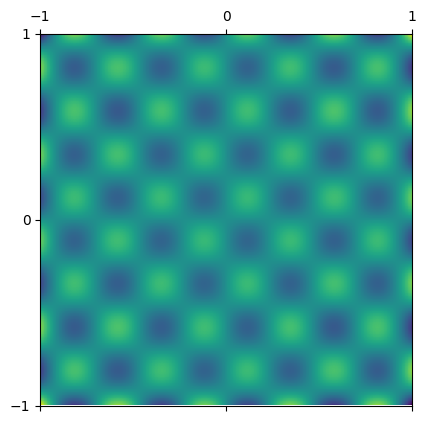

In [ ]:
show_waves(x, basis_set)

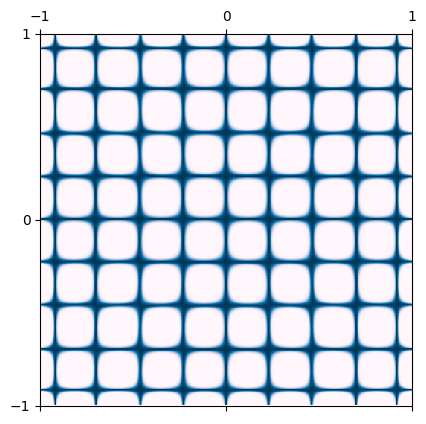

In [59]:
show_nodes(x, basis_set)

### Exercise c)

#### (1)

The function `rayleigh_iterate(A, x0, shift0, tol, max_iter)`, receives a matrix `A`, a random vector `x0`, an initial approximated eigenvalue `shift0` and returns a eigenvector `x` alongside the amount of iterations used `k`. The optional parameters serve as break control in a similar manner as previous exercises. Before the Rayleigh Iteration, the function computes 3 iterations of the *Shifted Inverse Iterate* to make the random vector `x` into a more approximated eigenvector. These extra iterations are not included in the $k$ measurements of the next exercises.

In [258]:
def qr_solve(A, b):
    Q, R = householder_QR_slow(A)
    y = Q.T @ b
    x = back_substitute(R, y)
    return x

def rayleigh_iterate(A, x0, shift0, tol=1e-12, max_iter=10000):
    n = A.shape[0]
    I = np.eye(n)
    

    x = x0 / np.linalg.norm(x0)
    shift = shift0

    for i in range(3):
        x = qr_solve(A - shift * I, x)
        x = x / np.linalg.norm(x)

    k = 0
    for k in range(1, max_iter + 1):
        shift = rayleight_qt(A, x)

        try:
            x_next = qr_solve(A - shift * I, x)
        except ZeroDivisionError:
            break

        x = x_next / np.linalg.norm(x_next)

        _, r = rayleigh_residual(A, x)
        if r <= tol:
            break

    return x, k

#### (2)

We test the function by trying to get a single eigenvalue out of the test matrices in `Project2_examplematrices.py`. As previously stated, the initial `x0` vector is randomly generated. As for the initially approximated eigenvalue `shift0`, it will be given as $0$ for now. Therefore, the eigenvalues presented below are not the largest eigenvalues anymore as it was done in previous exercises, but just a mere eigenvalue close to zero. It is also due to this that the later matrices `A4`, `A5`, and `A6`, require a single iteration, since zero already is a eigenvalue and the convergance check immediately breaks. Regardless, here are the results obtained:

Matrix | $\lambda_{found}$ | Residual | $k$ | Is a true $\lambda$ |
|---| ---|---| --- | ---|
|A1| -2.000 | 4.44e-16 | 4| Y |
|A2| 2.000 | 1.37e-12 | 4 | Y|
|A3| -0.959 | 8.60e-16 | 3 | Y |
|A4| -0.000 | 4.44e-16 |1 |Y |
|A5| 0.000| 1.20e-15| 1| Y|
|A6|0.000 | 8.49e-17|1 | Y|

In [268]:
test_pool = [A1, A2, A3, A4, A5, A6] 
label_pool = [eigvals1, eigvals2, eigvals3, eigvals4, eigvals5, eigvals6]

np.random.seed(67)

for i, A in enumerate(test_pool):
    A = A.astype(float)
    x0 = np.random.rand(A.shape[0])

    x, k = rayleigh_iterate(A, x0, shift0=0)

    lm = rayleight_qt(A, x)
    _, res = rayleigh_residual(A, x)

    print(f"Matrix A{i+1}:")
    
    print(f"RI Eigenvec = {x}")
    print(f"Rayleigh_qt Eigenvalue = {lm:.3f}")
    print(f"Residual = {res:.2e}")
    print(f"Iterations = {k}")
    print(f"Is eigenvalue? {any(abs(lm - ev) < 1e-08 for ev in label_pool[i])}")
    print(f"True Eigenvalues = {label_pool[i]}")
    print()

Matrix A1:
RI Eigenvec = [ 0.71 -0.71]
Rayleigh_qt Eigenvalue = -2.000
Residual = 4.44e-16
Iterations = 4
Is eigenvalue? True
True Eigenvalues = [4, -2]

Matrix A2:
RI Eigenvec = [-0.71  0.71]
Rayleigh_qt Eigenvalue = 2.000
Residual = 1.37e-12
Iterations = 4
Is eigenvalue? True
True Eigenvalues = [4, 2]

Matrix A3:
RI Eigenvec = [ 0.77 -0.64 -0.08]
Rayleigh_qt Eigenvalue = -0.959
Residual = 8.60e-16
Iterations = 3
Is eigenvalue? True
True Eigenvalues = [12.298958390970709, -4.4805737703355, -0.9585101385863923]

Matrix A4:
RI Eigenvec = [-0.41  0.82 -0.41]
Rayleigh_qt Eigenvalue = -0.000
Residual = 4.44e-16
Iterations = 1
Is eigenvalue? True
True Eigenvalues = [16.116843969807043, -1.116843969807043, 0]

Matrix A5:
RI Eigenvec = [-0.41  0.3   0.06  0.63 -0.58]
Rayleigh_qt Eigenvalue = 0.000
Residual = 1.20e-15
Iterations = 1
Is eigenvalue? True
True Eigenvalues = [68.6420807370024, -3.642080737002401, 0, 0, 0]

Matrix A6:
RI Eigenvec = [-0.02  0.76 -0.45 -0.15  0.44]
Rayleigh_qt Eigenv

### Exercise d)

#### (1)

*Power Iteration* works by repeatedly "stretching" a vector by the matrix until a favored direction takes shape, which is the direction of the dominant eigenvector. We can see this in a more mathematical manner as follows:

Let's say we have a matrix $A$ and the respective value of eigenvectors and values pairs $(v_i, \lambda_i)$. The starting vector `x0`, can then be written as a combination of these pairs, that is $x0 = c_1 v_1 + c_2 v_2 + \cdots + c_n v_n$. Since we know that $Av_i = \lambda_iv_i$ for all eigenvalues/vectors, we also know that by repeatedly multiplying the `x0` we are simply amplifying the effect of the dominant vector:

$$A^k x_0 = c_1 \lambda_1^k v_1 + c_2 \lambda_2^k v_2 + \dots + c_n \lambda_n^k v_n$$

$$\equiv A^k x_0 = \lambda_1^k \left( c_1 v_1 + \sum_{i=2}^{n} c_i \left( \frac{\lambda_i}{\lambda_1} \right)^{k} v_i \right)$$


Since we take $\lambda_1$ as the biggest eigenvalue, the factor $\frac{\lambda_i}{\lambda_1}$ goes to $0$ as $k$ goes to $\infty$. With this, and the normalization done after each step, every component except for $v_1$ disappears, leaving only the predominant direction. So, by construction, *Power Iteration* cannot possibly return a lower eigenvalue/vector.

#### (2)

The naive approach to getting all the eigenvectors is to simply make our initial guesses `shift0` into a number more plausible than simply zero. By using the previously developed function `gershgorin(A)`, that returns the centers and radii that contain the eigenvalues for `A`, we can make those centers the new initial guesses. This, returns 12 out of the 15 possible eigenvectors. The reason why that might happen is due to the overlap of the circles' boundaries, where some centers may be closer to an eigenvalue that was not supposed to be from that circle. *(Although, it is to note that in certain seeds 15 eigenvalues are found)*

The second approach is to consider the boundaries of the gershgorin circles as well rather than just their centers. Instead of making one calculation per circle, I instead compute 3: One for the center, and two for each boundary, and only collect unique eigenvalues from these results. This approach consistently computes 15 unique eigenvalues, which are displayed in the table below. In last cell respective to this exercise, we can also verify that the nodes of the lowest valued eigenvector follows the behavior that was expected.

|$\lambda_{found}$ | Residual | $k$ |
| --- |---| --- |
| 13.89261 | 2.423e-15 | 1 |
|86.88022  | 1.482e-10| 1|
|286.53331  | 5.684e-14|4 |
|1132.21657  | 2.274e-13|2 |
|1799.80589  | 6.821e-13| 3|
|5560.88120  | 9.095e-10| 3 |
|11485.21283  | 5.457e-12 | 4 |
|13338.62230  | 3.629e-10| 2 |
|22590.19852  | 1.846e-09| 2|
|32779.07108  | 1.091e-11|3 |
|36152.36997  | 7.276e-12| 5 |
|50430.02765  | 1.455e-11| 4|
|52766.28876  | 4.555e-09| 4 |
| 93999.61413 |2.910e-11 | 3 |
|151362.66649  | 1.804e-09 | 2 |

*Note: this is not to say the approach that I have came up with is completely fool-proof for any matrix, just that it worked properly and consistently for matrix K in this case*

In [269]:
np.set_printoptions(precision=2, suppress=True)

true_eigenvalues = np.linalg.eigvals(Kmat)
print(true_eigenvalues)

np.random.seed(67)

print()
centers, radii = gershgorin(Kmat)
print(f"{len(centers)} circles for K")
print(centers)

[151362.67  93999.61  52766.29  50430.03  36152.37  32779.07  22590.2
  13338.62  11485.21   5560.88   1799.81   1132.22    286.53     86.88
     13.89]

15 circles for K
[129292.22 103041.44  64967.58  43612.41  36273.75  37990.1   24166.97
  11651.16  13865.08   5600.55   1173.04   1760.77    288.42     86.9
     13.89]


In [270]:
#NAIVE APPROACH

np.set_printoptions(precision=5, suppress=True)
np.random.seed(67)

found_eigenvals = []
for i in range(len(centers)):
    
    Kmat = Kmat.astype(float)
    x0 = np.random.rand(Kmat.shape[0])

    x, k = rayleigh_iterate(Kmat, x0, shift0=centers[i], tol=1e-08)

    lm = rayleight_qt(Kmat, x)
    
    if not any(abs(lm - ev[0]) < 1e-08 for ev in found_eigenvals):
        found_eigenvals.append([lm, x])
        _, res = rayleigh_residual(Kmat, x)
        print(f"New eigenval: {lm:.5f} at k={k}, shift={centers[i]:.5f}, residual={res:.3e}")
    
    
    
print()  
print(f"{len(found_eigenvals)} unique eigenvalues")

    

New eigenval: 93999.61413 at k=4, shift=129292.21921, residual=2.183e-11
New eigenval: 52766.28876 at k=3, shift=64967.57873, residual=3.638e-12
New eigenval: 36152.36997 at k=5, shift=43612.41191, residual=7.276e-12
New eigenval: 22590.19852 at k=3, shift=24166.97112, residual=2.728e-12
New eigenval: 11485.21283 at k=2, shift=11651.15869, residual=3.638e-12
New eigenval: 13338.62230 at k=2, shift=13865.08046, residual=2.274e-12
New eigenval: 5560.88120 at k=1, shift=5600.54767, residual=6.321e-11
New eigenval: 1132.21657 at k=2, shift=1173.03879, residual=2.274e-13
New eigenval: 1799.80589 at k=2, shift=1760.77135, residual=6.821e-13
New eigenval: 286.53331 at k=1, shift=288.42306, residual=2.429e-13
New eigenval: 86.88022 at k=1, shift=86.89689, residual=3.547e-14
New eigenval: 13.89261 at k=1, shift=13.89335, residual=2.708e-15

12 unique eigenvalues


In [271]:
#NOT SO NAIVE APPROACH

np.set_printoptions(precision=5, suppress=True)
np.random.seed(67)

found_eigenvals = []
for i in range(len(centers)):
    
    
    Kmat = Kmat.astype(float)
    x0 = np.random.rand(Kmat.shape[0])

    for guess in [centers[i] - radii[i], centers[i], centers[i] + radii[i]]:
        x, k = rayleigh_iterate(Kmat, x0, shift0=guess, tol=1e-08)

        lm = rayleight_qt(Kmat, x)


        if not any(abs(lm - ev[0]) < 1e-08 for ev in found_eigenvals): 
            found_eigenvals.append([lm, x])
            _, res = rayleigh_residual(Kmat, x)
            print(f"New eigenval: {lm:.5f} at k={k}, shift={centers[i]:.5f}, residual={res:.3e}")
    
    
    
print()  
print(f"{len(found_eigenvals)} unique eigenvalues")

New eigenval: 93999.61413 at k=3, shift=129292.21921, residual=2.910e-11
New eigenval: 52766.28876 at k=4, shift=103041.43942, residual=4.555e-09
New eigenval: 151362.66649 at k=2, shift=103041.43942, residual=1.804e-09
New eigenval: 32779.07108 at k=3, shift=64967.57873, residual=1.091e-11
New eigenval: 22590.19852 at k=2, shift=43612.41191, residual=1.846e-09
New eigenval: 36152.36997 at k=5, shift=43612.41191, residual=7.276e-12
New eigenval: 50430.02765 at k=4, shift=36273.75152, residual=1.455e-11
New eigenval: 11485.21283 at k=4, shift=24166.97112, residual=5.457e-12
New eigenval: 13338.62230 at k=2, shift=11651.15869, residual=3.629e-10
New eigenval: 5560.88120 at k=3, shift=13865.08046, residual=9.095e-13
New eigenval: 286.53331 at k=4, shift=1173.03879, residual=5.684e-14
New eigenval: 1132.21657 at k=2, shift=1173.03879, residual=2.274e-13
New eigenval: 1799.80589 at k=3, shift=1173.03879, residual=6.821e-13
New eigenval: 86.88022 at k=1, shift=86.89689, residual=1.482e-10
Ne

13.89261 vs 13.89261, diff = 1.776e-15
86.88022 vs 86.88022, diff = 4.263e-14
286.53331 vs 286.53331, diff = 5.116e-13
1132.21657 vs 1132.21657, diff = 6.821e-13
1799.80589 vs 1799.80589, diff = 6.821e-13
5560.88120 vs 5560.88120, diff = 3.638e-12
11485.21283 vs 11485.21283, diff = 3.638e-12
13338.62230 vs 13338.62230, diff = 2.365e-11
22590.19852 vs 22590.19852, diff = 6.912e-11
32779.07108 vs 32779.07108, diff = 3.638e-11
36152.36997 vs 36152.36997, diff = 2.910e-11
50430.02765 vs 50430.02765, diff = 2.183e-11
52766.28876 vs 52766.28876, diff = 2.183e-11
93999.61413 vs 93999.61413, diff = 5.821e-11
151362.66649 vs 151362.66649, diff = 1.455e-10


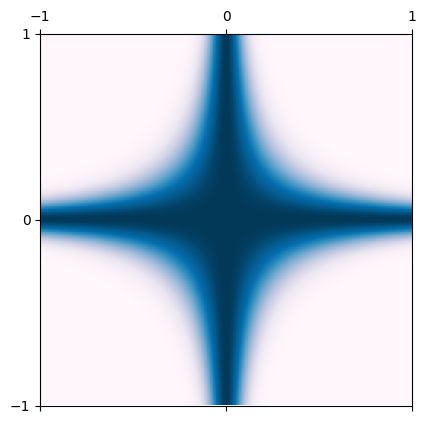

In [272]:
ordered_unique = sorted(found_eigenvals)
ordered_true = sorted(true_eigenvalues)

for i in range(min(len(ordered_unique), len(ordered_true))):
    print(f"{ordered_unique[i][0]:.5f} vs {ordered_true[i]:.5f}, diff = {abs(ordered_unique[i][0] - ordered_true[i]):.3e}")
    
    
show_nodes(ordered_unique[0][1], basis_set)

#### (3)

Now knowing all the eigenvalues and corresponding eigenvectors, we can deconstruct matrix `Kmat` into `P` and `D` (sometimes by other names), which are the matrices containing the eigenvectors aligned in collumns, and the corresponding eigenvalues in the diagonal, respectively. With this we can use the fact that $PDP^{-1} = K$ to reconstruct matrix `Kmat`, which is verified in the cell below.

In [238]:
D = np.diag([ev[0] for ev in ordered_unique])
P = np.column_stack([ev[1] for ev in ordered_unique])
    
print(f"Kmat = P D P^-1? {"Yeahhh" if np.allclose(Kmat, P @ D @ np.linalg.inv(P)) else "Nope"}")    

Kmat = P D P^-1? Yeahhh


#### (4)

The next and final section depicts all the node graphs for each eigenvalue obtained in the previous exercises. As it was predicted theoretically, each eigenvalue, or resonnance frequency, makes the nodes be displayed in a "beautiful pattern", rather than a random assortment of noise.

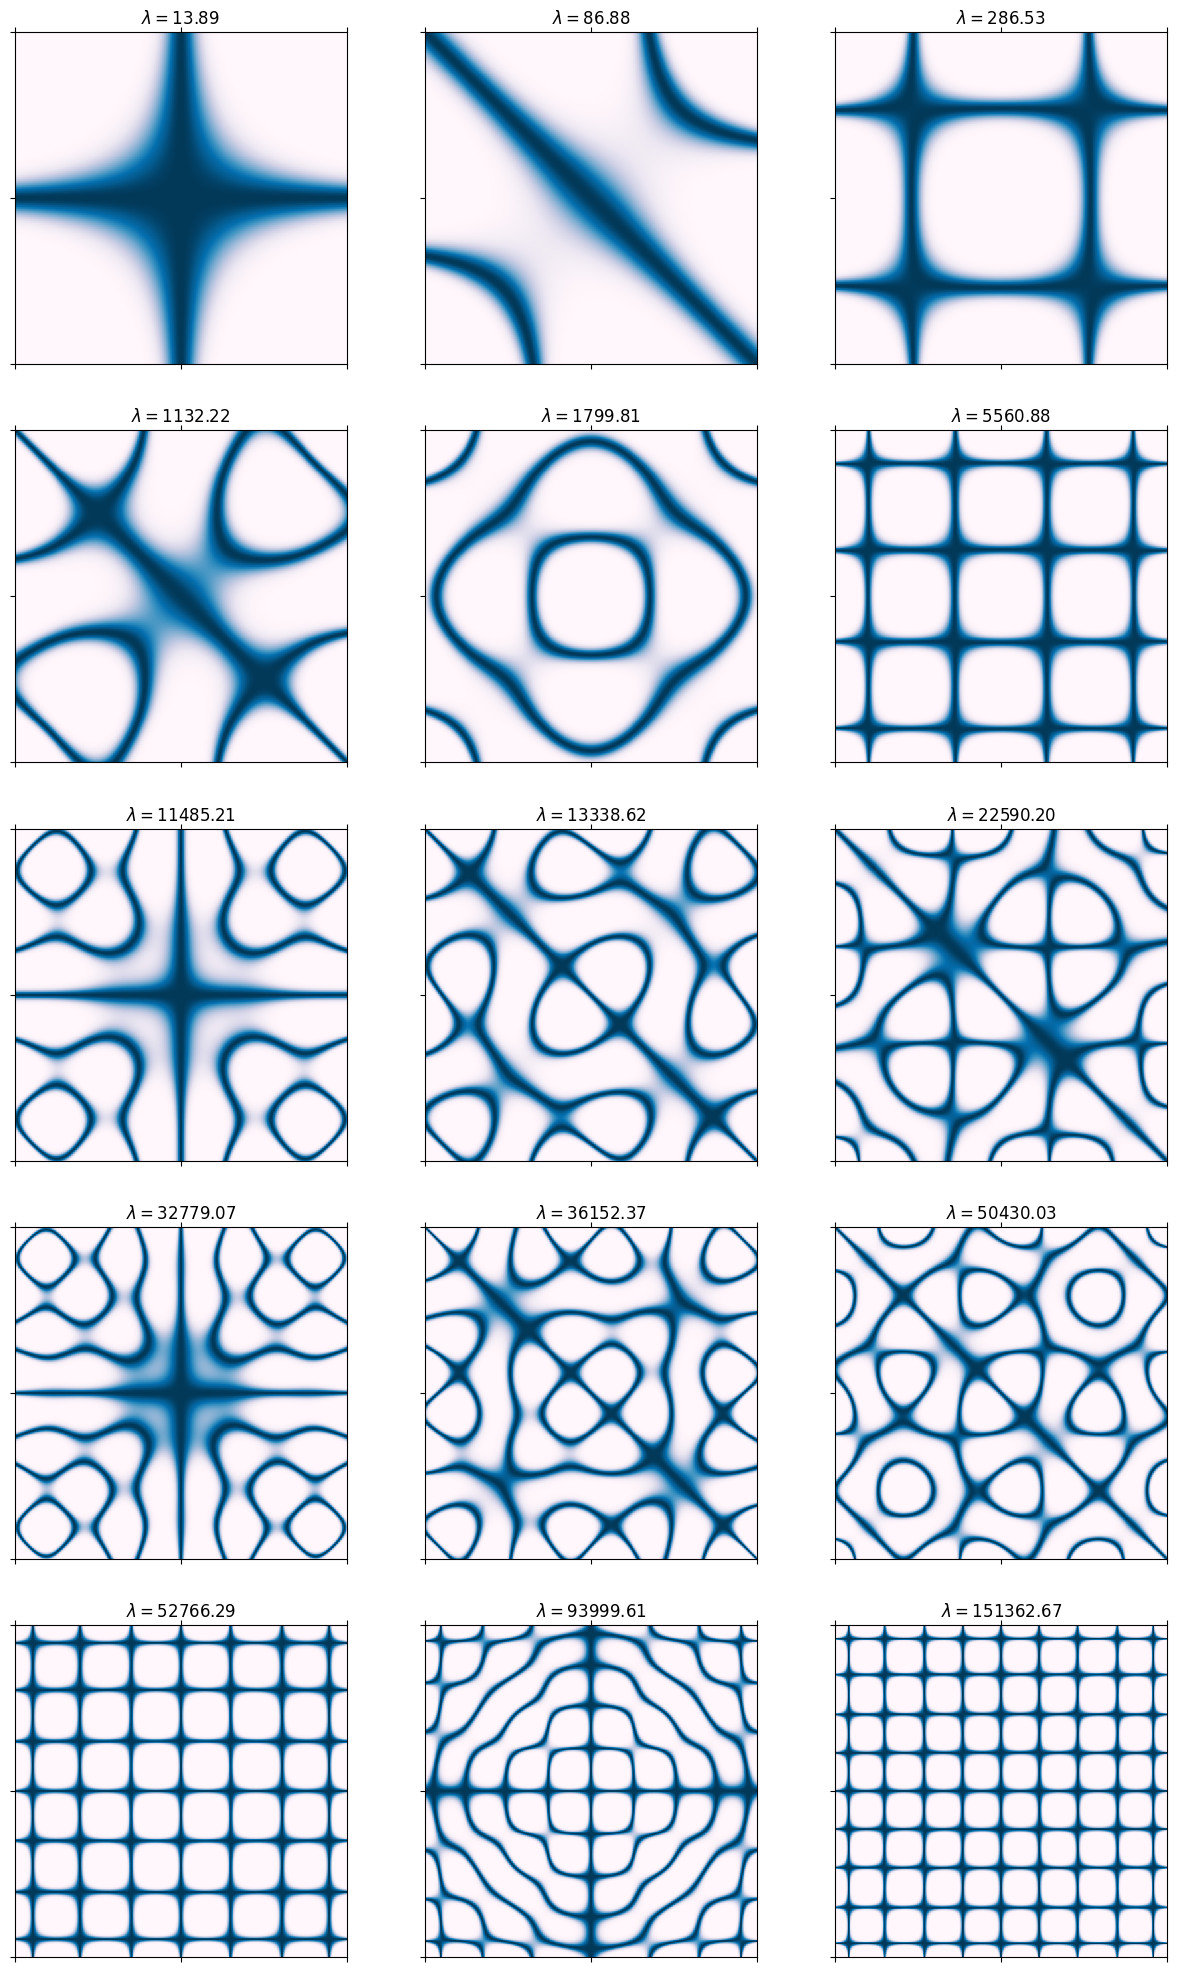

In [ ]:
from chladni_show import show_all_wavefunction_nodes

lambdas = np.array([ev[0] for ev in ordered_unique])
show_all_wavefunction_nodes(P, lambdas, basis_set)